In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pydantic import BaseModel
from openai import OpenAI
from langchain_openai import OpenAIEmbeddings
from sklearn.metrics.pairwise import cosine_similarity
from textstat import flesch_reading_ease
pd.options.mode.chained_assignment = None 

In [2]:
mcqs = pd.read_pickle("mcqs.pkl")
mcqs

,id,stem,a,b,c,d,correct_answer,hidden_middle_entity,is_multihop,helper_triple_used,degree_centralities,page_ranks,distractor_depths,node_embedding_similarity_scores,triple,quintuple,helper_triple,incorrect_rate
0,1,"Born in the German Empire, which theoretical p...",Albert Einstein,Elon Reeve Musk,Lionel Andrés Messi,Eva Braun,A,None,False,False,"[35, 1]","[13.96, 0.49]","[4, 4, 2]","[-0.01, -0.1, 0.4]","[Albert Einstein, Person, BORN_IN, ->, German ...",None,None,0.131579
1,2,Renowned for developing the Theory of Relativi...,Dennis Wilson,Stephen William Hawking,Albert Einstein,Karim Benzema,C,None,False,True,"[1, 35, 1]","[0.49, 13.96, 0.49]","[5, 2, 5]","[0.01, 0.05, -0.04]","[Albert Einstein, Person, BENEFICIAL_TO, ->, Q...",None,"[Albert Einstein, Person, DEVELOPED, ->, Theor...",0.184211
2,3,"A renowned physicist, who played a significant...",Thomas Jefferson,Nicki Minaj,Albert Einstein,Hillary Clinton,C,World War II,True,False,"[35, 17, 23]","[13.96, 5.4, 8.64]","[4, 4, 4]","[0.04, -0.03, 0.17]",None,"[Albert Einstein, Person, CONTEXT_OF, ->, Worl...",None,0.090909
3,4,"What influential physicist, known for proposin...",Albert Einstein,Chuck Norris,Prince Philip,Richard Nixon,A,Adolf Hitler,True,True,"[26, 24, 35, 2]","[9.32, 8.85, 13.96, 0.95]","[3, 5, 3]","[0.09, -0.04, 0.11]",None,"[World War I, Event, PARTICIPATED_IN, <-, Adol...","[Albert Einstein, Person, PROPOSED, ->, Genera...",0.121212
4,5,Who is the acclaimed actor and director known ...,Neil Patrick Harris,Rob Greenberg,Angelina Jolie,Donald Trump,C,None,False,False,"[33, 8]","[13.11, 2.85]","[5, 5, 5]","[0.11, 0.11, 0.05]","[Angelina Jolie, Person, RECIPIENT_OF, ->, Gol...",None,None,0.243243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,152,"In 1914, the United Kingdom declared war on a ...",Sino-Soviet Split,Indochina Wars,Reactor Core Fire,World War I,D,Germany,True,True,"[28, 53, 26, 1]","[9.18, 18.29, 9.32, 0.45]","[5, 4, 3]","[0.1, -0.04, 0.08]",None,"[United Kingdom, Country, DECLARED_WAR, ->, Ge...","[World War I, Event, CHARACTERISTIC, ->, Tanks...",0.189189
152,153,By what name is the artist born as Kanye Omari...,Ye,Tim Burton,Kareem Abdul-Jabbar,Colonel Tom Parker,A,None,False,False,"[46, 1]","[18.52, 0.49]","[5, 4, 3]","[-0.07, -0.08, -0.01]","[Ye, Person, ALIAS, ->, Kanye Omari West, Person]",None,None,0.239130
153,154,"Which individual, known for creating the album...",Scarlett Ingrid Johansson,Tony Bennett,Lionel Messi,Ye,D,None,False,True,"[2, 46, 1]","[0.83, 18.52, 0.49]","[2, 4, 4]","[-0.03, 0, -0.05]","[Ye, Person, FEATURED_IN, ->, Rolling Stone, P...",None,"[Ye, Person, CREATED, ->, 808s & Heartbreak, A...",0.545455
154,155,"Which renowned musician, like Elvis Aaron Pres...",Sam Phillips,Kid Cudi,Ye,Bill Black,C,Grammy Awards,True,False,"[46, 8, 25]","[18.52, 2.75, 9.63]","[3, 1, 3]","[0, 1, -0.01]",None,"[Ye, Person, WON, ->, Grammy Awards, Award, WO...",None,0.551724


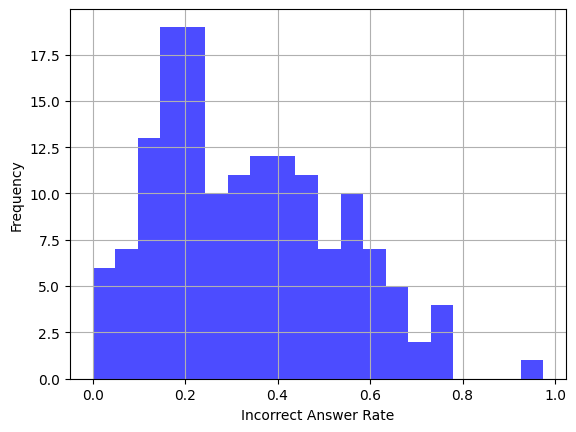

In [3]:
plt.hist(mcqs['incorrect_rate'], bins=20, color='blue', alpha=0.7)
plt.xlabel('Incorrect Answer Rate')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [4]:
# Signal Reasoning
mcqs["signal_reasoning"] = mcqs["is_multihop"].apply(
    lambda x: np.float64(1.0) if x else np.float64(0.0)
)

In [5]:
# Signal Extra Triple
mcqs["signal_extra_triple"] = mcqs["helper_triple_used"].apply(
    lambda x: np.float64(0.0) if x else np.float64(1.0)
)

In [6]:
# Signal Distractor Depth
min_distractor_depth, max_distractor_depth = np.float64(1.0), np.float64(5.0)
mcqs["signal_distractor_depth"] = mcqs["distractor_depths"].apply(
    lambda x: np.float64(
        1.0
        - np.mean(
            [
                (np.float64(depth) - min_distractor_depth)
                / (max_distractor_depth - min_distractor_depth)
                for depth in x
            ]
        )
    )
)

In [7]:
# Signal Node Embedding Similarity
mcqs["signal_node_embedding_similarity"] = mcqs[
    "node_embedding_similarity_scores"
].apply(lambda lst: np.float64(np.mean([(np.float64(x) + 1) / 2 for x in lst])))

In [8]:
# Signal Text Embedding Similarity
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
for col in ["stem", "a", "b", "c", "d"]:
    mcqs[f"{col}_embedding"] = mcqs[col].apply(lambda x: embeddings.embed_query(x))
for opt in ["a", "b", "c", "d"]:
    mcqs[f"cosine_similarity_stem_{opt}"] = mcqs.apply(
        lambda row: cosine_similarity(
            [row["stem_embedding"]], [row[f"{opt}_embedding"]]
        )[0][0],
        axis=1,
    )


def calculate_signal_text_embedding_similarity(row):
    correct_option = row["correct_answer"].lower()
    incorrect_options = ["a", "b", "c", "d"]
    incorrect_options.remove(correct_option)
    correct_similarity = row[f"cosine_similarity_stem_{correct_option}"]
    incorrect_similarities = [
        row[f"cosine_similarity_stem_{opt}"] for opt in incorrect_options
    ]

    return np.mean(incorrect_similarities) / correct_similarity


mcqs["signal_text_embedding_similarity"] = mcqs.apply(calculate_signal_text_embedding_similarity, axis=1)
mcqs["signal_text_embedding_similarity"] = mcqs["signal_text_embedding_similarity"].apply(
    lambda x: x if x <= 1 else 1
)

In [9]:
# Signal Degree Centrality
with open("centrality_stats.pkl", "rb") as f:
    centrality_stats = pickle.load(f)
degree_centrality_min, degree_centrality_max = np.float64(
    centrality_stats["degree"]["min"]
), np.float64(centrality_stats["degree"]["max"])
mcqs["signal_degree_centrality"] = mcqs["degree_centralities"].apply(
    lambda lst: np.float64(
        1.0
        - np.float64(
            np.mean(
                [
                    (np.float64(x) - degree_centrality_min)
                    / (degree_centrality_max - degree_centrality_min)
                    for x in lst
                ]
            )
        )
    )
)

In [10]:
# Signal Readability
def calculate_readability(text):
    return flesch_reading_ease(text)
mcqs["readability"] = mcqs["stem"].apply(calculate_readability)
min_readability = mcqs['readability'].min()
max_readability = mcqs['readability'].max()
mcqs['signal_readability'] = (mcqs['readability'] - min_readability) / (max_readability - min_readability)

In [11]:
# Signal Above Largest Gap Count
def calculate_gap_and_above(row):
    similarities = sorted(
        [
            row["cosine_similarity_stem_a"],
            row["cosine_similarity_stem_b"],
            row["cosine_similarity_stem_c"],
            row["cosine_similarity_stem_d"],
        ],
        reverse=True,
    )
    differences = [
        similarities[i] - similarities[i + 1] for i in range(len(similarities) - 1)
    ]
    largest_gap = max(differences)
    gap1, gap2, gap3 = differences
    if gap1 == largest_gap:
        above_gap_count = 1
    elif gap2 == largest_gap:
        above_gap_count = 2
    elif gap3 == largest_gap:
        above_gap_count = 3
    else:
        raise ValueError("Largest gap not found in the differences.")
    return gap1, gap2, gap3, largest_gap, above_gap_count


mcqs[["gap1", "gap2", "gap3", "largest_gap", "above_gap_count"]] = mcqs.apply(
    calculate_gap_and_above, axis=1, result_type="expand"
)

mcqs[["id", "largest_gap", "above_gap_count"]].head()

mcqs["signal_above_largest_gap_count"] = (mcqs["above_gap_count"] - 1) / (3 - 1)

In [12]:
# Signal LLM Extra Fact
def get_triples(row):
    triples = []
    if row["triple"]:
        triples.append(row["triple"])
    if row["quintuple"]:
        triples.append(row["quintuple"])
    if row["helper_triple"]:
        triples.append(row["helper_triple"])
    return triples


mcqs["combined_triples"] = mcqs.apply(get_triples, axis=1)


class ContainsExtraFact(BaseModel):
    output: bool
    extra_fact: str


client = OpenAI()


def check_extra_hint(row):
    prompt = f"Does the following stem contain any additional fact that is not provided in the combined_triples?\n\nStem: {row['stem']}\nCombined Triples: {row['combined_triples']}\n\nIf the stem contains any additional fact, make the output field True, and write the extra fact in the extra_fact field. Otherwise, make the output field False, leave the extra_fact field empty.\n\n"

    completion = client.beta.chat.completions.parse(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt},
        ],
        response_format=ContainsExtraFact,
    )

    response = completion.choices[0].message.parsed
    output, extra_fact = response.output, response.extra_fact
    return 0 if output else 1, extra_fact


mcqs[["signal_llm_extra_fact", "extra_fact"]] = mcqs.apply(
    lambda row: pd.Series(check_extra_hint(row)), axis=1
)

In [13]:
df = mcqs[
    [
        "id",
        "stem",
        "a",
        "b",
        "c",
        "d",
        "correct_answer",
        "incorrect_rate",
        "signal_reasoning",
        "signal_extra_triple",
        "signal_distractor_depth",
        "signal_node_embedding_similarity",
        "signal_text_embedding_similarity",
        "signal_degree_centrality",
        "signal_readability",
        "signal_above_largest_gap_count",
        "signal_llm_extra_fact",
    ]
]
df

,id,stem,a,b,c,d,correct_answer,incorrect_rate,signal_reasoning,signal_extra_triple,signal_distractor_depth,signal_node_embedding_similarity,signal_text_embedding_similarity,signal_degree_centrality,signal_readability,signal_above_largest_gap_count,signal_llm_extra_fact
0,1,"Born in the German Empire, which theoretical p...",Albert Einstein,Elon Reeve Musk,Lionel Andrés Messi,Eva Braun,A,0.131579,0.0,1.0,0.416667,0.548333,0.322104,0.660379,0.229622,0.0,0
1,2,Renowned for developing the Theory of Relativi...,Dennis Wilson,Stephen William Hawking,Albert Einstein,Karim Benzema,C,0.184211,0.0,0.0,0.250000,0.503333,0.260010,0.767297,0.229622,0.0,1
2,3,"A renowned physicist, who played a significant...",Thomas Jefferson,Nicki Minaj,Albert Einstein,Hillary Clinton,C,0.090909,1.0,1.0,0.250000,0.530000,0.216290,0.528304,0.356575,0.0,0
3,4,"What influential physicist, known for proposin...",Albert Einstein,Chuck Norris,Prince Philip,Richard Nixon,A,0.121212,1.0,0.0,0.333333,0.526667,0.277361,0.589625,0.268905,0.0,1
4,5,Who is the acclaimed actor and director known ...,Neil Patrick Harris,Rob Greenberg,Angelina Jolie,Donald Trump,C,0.243243,0.0,1.0,0.000000,0.545000,0.529586,0.613209,0.558968,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,152,"In 1914, the United Kingdom declared war on a ...",Sino-Soviet Split,Indochina Wars,Reactor Core Fire,World War I,D,0.189189,1.0,0.0,0.250000,0.523333,0.233798,0.490568,0.732613,0.0,0
152,153,By what name is the artist born as Kanye Omari...,Ye,Tim Burton,Kareem Abdul-Jabbar,Colonel Tom Parker,A,0.239130,0.0,1.0,0.250000,0.473333,0.714083,0.556606,0.821802,0.5,1
153,154,"Which individual, known for creating the album...",Scarlett Ingrid Johansson,Tony Bennett,Lionel Messi,Ye,D,0.545455,0.0,0.0,0.416667,0.486667,0.919837,0.691825,0.492456,1.0,1
154,155,"Which renowned musician, like Elvis Aaron Pres...",Sam Phillips,Kid Cudi,Ye,Bill Black,C,0.551724,1.0,1.0,0.666667,0.665000,1.000000,0.503147,0.438086,0.5,1


In [14]:
df.to_pickle("df.pkl")
df.to_csv("df.csv", index=False)